# Part D: Signal Data

**Dataset:** MIT-BIH Arrhythmia Database (ECG)  
**Objective:** Data acquisition & inspection, preprocessing (signal windows), EDA, Feature Engineering/Selection/Extraction, Noise Removal, and Augmentation on medical signal data.

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print("Core libraries loaded.")

Core libraries loaded.


In [23]:
import wfdb
import scipy.signal as signal
from scipy.fft import fft, fftfreq
from scipy.stats import skew, kurtosis
# import pywt

print("Signal processing libraries loaded.")

Signal processing libraries loaded.


In [24]:
# Download records from PhysioNet
# The MIT-BIH Arrhythmia Database record names are 100-103, 105-111, 113-119, 121-123, 200-203, 205, 207-210, 212-214, 219-221, 223, 228, 230-234
record_names = ['100', '101', '102', '103', '104', '105', '106', '107',
                '108', '109', '111', '112', '113', '114', '115', '116',
                '117', '118', '119', '121', '122', '123', '200', '201',
                '202', '203', '205', '207', '208', '209', '210', '212',
                '213', '214', '215', '217', '219', '220', '221', '222',
                '223', '228', '230', '231', '232', '233', '234']

# Download using wfdb
wfdb.io.dl_database('mitdb', dl_dir='./mitdb_data')

print(f"Downloaded {len(record_names)} records.")
print(f"Data directory: ./mitdb_data")

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [25]:
data_dir = './mitdb_data'
records = []

for name in record_names:
    rec_path = os.path.join(data_dir, name)
    if os.path.exists(rec_path + '.hea'):
        record = wfdb.rdrecord(rec_path)
        ann = wfdb.rdann(rec_path, 'atr')
        # Find MLII channel index, fallback to first channel
        if 'MLII' in record.sig_name:
            ch_idx = record.sig_name.index('MLII')
        else:
            ch_idx = 0
        records.append({'name': name, 'record': record, 'annotation': ann, 'ch_idx': ch_idx})
        print(f"Loaded record {name}: channels={record.sig_name}, using ch[{ch_idx}]={record.sig_name[ch_idx]}, {record.p_signal.shape[0]} samples, fs={record.fs} Hz")
    else:
        print(f"Record {name} not found, skipping.")

Loaded record 100: channels=['MLII', 'V5'], using ch[0]=MLII, 650000 samples, fs=360 Hz
Loaded record 101: channels=['MLII', 'V1'], using ch[0]=MLII, 650000 samples, fs=360 Hz
Loaded record 102: channels=['V5', 'V2'], using ch[0]=V5, 650000 samples, fs=360 Hz
Loaded record 103: channels=['MLII', 'V2'], using ch[0]=MLII, 650000 samples, fs=360 Hz
Loaded record 104: channels=['V5', 'V2'], using ch[0]=V5, 650000 samples, fs=360 Hz
Loaded record 105: channels=['MLII', 'V1'], using ch[0]=MLII, 650000 samples, fs=360 Hz
Loaded record 106: channels=['MLII', 'V1'], using ch[0]=MLII, 650000 samples, fs=360 Hz
Loaded record 107: channels=['MLII', 'V1'], using ch[0]=MLII, 650000 samples, fs=360 Hz
Loaded record 108: channels=['MLII', 'V1'], using ch[0]=MLII, 650000 samples, fs=360 Hz
Loaded record 109: channels=['MLII', 'V1'], using ch[0]=MLII, 650000 samples, fs=360 Hz
Loaded record 111: channels=['MLII', 'V1'], using ch[0]=MLII, 650000 samples, fs=360 Hz
Loaded record 112: channels=['MLII', 'V1

In [26]:
# Inspect a single record in detail
rec = records[0]
r = rec['record']
a = rec['annotation']

print(f"Record Name    : {rec['name']}")
print(f"Signal Names   : {r.sig_name}")
print(f"Using Channel  : {r.sig_name[rec['ch_idx']]} (index {rec['ch_idx']})")
print(f"Sampling Freq  : {r.fs} Hz")
print(f"Signal Shape   : {r.p_signal.shape}  (samples x channels)")
print(f"Duration       : {r.p_signal.shape[0] / r.fs:.1f} seconds")
print(f"Gain           : {r.adc_gain}")
print(f"Baseline       : {r.baseline}")
print(f"Total annotations: {len(a.sample)}")
print(f"\nAnnotation symbols (first 30): {list(a.symbol[:30])}")

Record Name    : 100
Signal Names   : ['MLII', 'V5']
Using Channel  : MLII (index 0)
Sampling Freq  : 360 Hz
Signal Shape   : (650000, 2)  (samples x channels)
Duration       : 1805.6 seconds
Gain           : [200.0, 200.0]
Baseline       : [1024, 1024]
Total annotations: 2274

Annotation symbols (first 30): ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [27]:
# Look at unique beat annotations across all records
all_symbols = []
for rec in records:
    all_symbols.extend(rec['annotation'].symbol)

symbol_counts = Counter(all_symbols)
print("Beat annotation symbols across all records:")
for sym, count in symbol_counts.most_common():
    print(f"  '{sym}': {count} occurrences")

Beat annotation symbols across all records:
  'N': 75052 occurrences
  'L': 8075 occurrences
  'V': 7083 occurrences
  '/': 7028 occurrences
  'R': 5728 occurrences
  'A': 2544 occurrences
  '+': 1278 occurrences
  'f': 982 occurrences
  'F': 798 occurrences
  '~': 614 occurrences
  '!': 472 occurrences
  '"': 437 occurrences
  'j': 224 occurrences
  'x': 193 occurrences
  'a': 150 occurrences
  '|': 132 occurrences
  'E': 106 occurrences
  'J': 54 occurrences
  'Q': 33 occurrences
  'e': 16 occurrences
  '[': 6 occurrences
  ']': 6 occurrences
  'S': 2 occurrences


In [28]:
# AAMI beat annotation mapping
AAMI_MAP = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q',
}

# Count beats per AAMI class
aami_counts = Counter()
for sym, count in symbol_counts.items():
    mapped = AAMI_MAP.get(sym)
    if mapped:
        aami_counts[mapped] += count

print("AAMI class distribution:")
for cls, count in aami_counts.most_common():
    print(f"  {cls}: {count}")
print(f"  Total mapped beats: {sum(aami_counts.values())}")

AAMI class distribution:
  N: 89095
  Q: 8043
  V: 7189
  S: 2750
  F: 798
  Total mapped beats: 107875


In [29]:
# Extract fixed-length beat windows centred on each R-peak
BEAT_WINDOW = 186   # samples on each side → 372 total at 360 Hz

beat_signals = []   # (windowed_signal, mapped_class)
unmapped_count = 0

for rec in records:
    sig = rec['record'].p_signal[:, rec['ch_idx']]   # lead MLII (or fallback)
    ann = rec['annotation']

    for idx, (sample, sym) in enumerate(zip(ann.sample, ann.symbol)):
        aami_cls = AAMI_MAP.get(sym)
        if aami_cls is None:
            unmapped_count += 1
            continue

        # Extract window (skip beats near boundaries)
        if sample - BEAT_WINDOW < 0 or sample + BEAT_WINDOW >= len(sig):
            continue

        window = sig[sample - BEAT_WINDOW : sample + BEAT_WINDOW]
        beat_signals.append((window, aami_cls))

print(f"Extracted {len(beat_signals)} beats  (skipped {unmapped_count} unmapped annotations)")
print(f"Class counts: {Counter(c for _, c in beat_signals)}")

Extracted 107819 beats  (skipped 3138 unmapped annotations)
Class counts: Counter({'N': 89046, 'Q': 8038, 'V': 7188, 'S': 2750, 'F': 797})


In [30]:
# Normalize each beat window to zero-mean, unit-variance
beats = np.array([b for b, _ in beat_signals], dtype=np.float32)
labels = np.array([c for _, c in beat_signals])

# Z-score normalization per beat
means = beats.mean(axis=1, keepdims=True)
stds  = beats.std(axis=1, keepdims=True)
stds[stds == 0] = 1  # avoid division by zero
beats_norm = (beats - means) / stds

print(f"Beats array shape : {beats_norm.shape}")
print(f"Labels array shape: {labels.shape}")
print(f"Labels distribution: {dict(Counter(labels))}")

Beats array shape : (107819, 372)
Labels array shape: (107819,)
Labels distribution: {np.str_('N'): 89046, np.str_('S'): 2750, np.str_('V'): 7188, np.str_('Q'): 8038, np.str_('F'): 797}


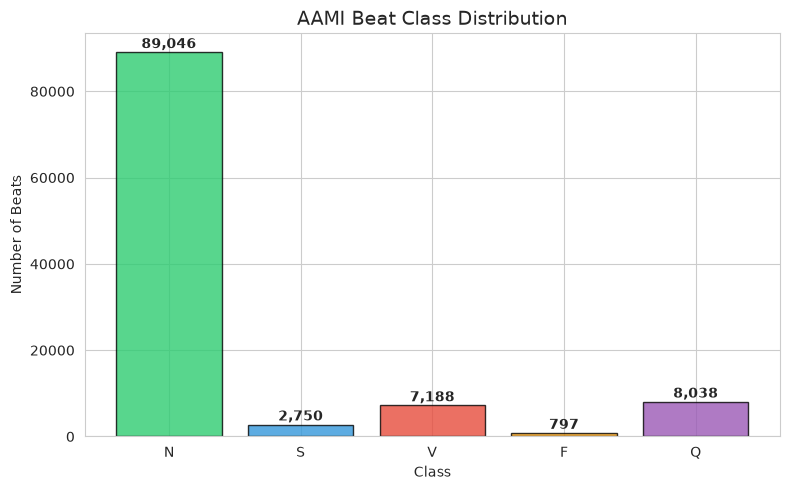

Class imbalance ratio (max/min): 111.7x


In [31]:
### 4.1 Class Distribution

fig, ax = plt.subplots(figsize=(8, 5))
cls_counts = Counter(labels)
classes_order = ['N', 'S', 'V', 'F', 'Q']
counts = [cls_counts.get(c, 0) for c in classes_order]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']

bars = ax.bar(classes_order, counts, color=colors, edgecolor='black', alpha=0.8)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{c:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('AAMI Beat Class Distribution', fontsize=14)
ax.set_xlabel('Class')
ax.set_ylabel('Number of Beats')
plt.tight_layout()
plt.show()

print(f"Class imbalance ratio (max/min): {max(counts)/min(counts):.1f}x")

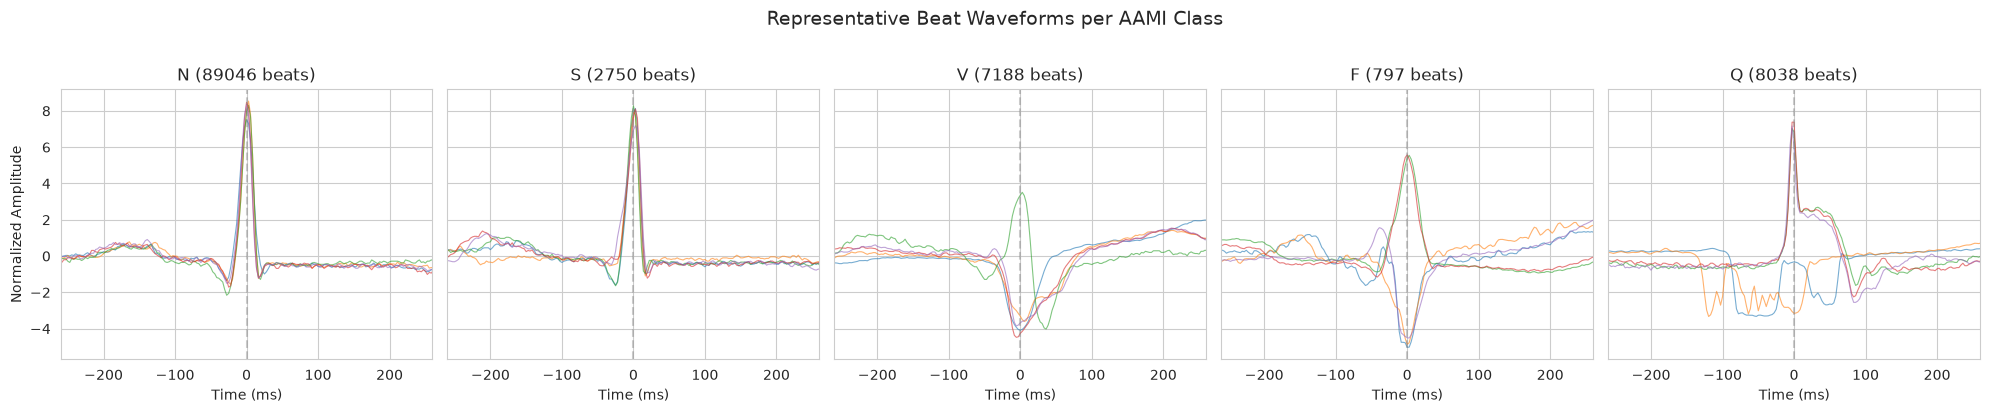

In [32]:
### 4.2 Sample ECG Beat Waveforms

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
x_axis = np.arange(-BEAT_WINDOW, BEAT_WINDOW) / 360.0 * 1000  # ms

for ax, cls in zip(axes, classes_order):
    idxs = np.where(labels == cls)[0]
    n_show = min(5, len(idxs))
    for j in range(n_show):
        ax.plot(x_axis, beats_norm[idxs[j]], alpha=0.6, linewidth=0.8)
    ax.set_title(f'{cls} ({len(idxs)} beats)', fontsize=12)
    ax.set_xlabel('Time (ms)')
    ax.axvline(0, color='gray', linestyle='--', alpha=0.4, label='R-peak')
    ax.set_xlim([-260, 260])

axes[0].set_ylabel('Normalized Amplitude')
plt.suptitle('Representative Beat Waveforms per AAMI Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

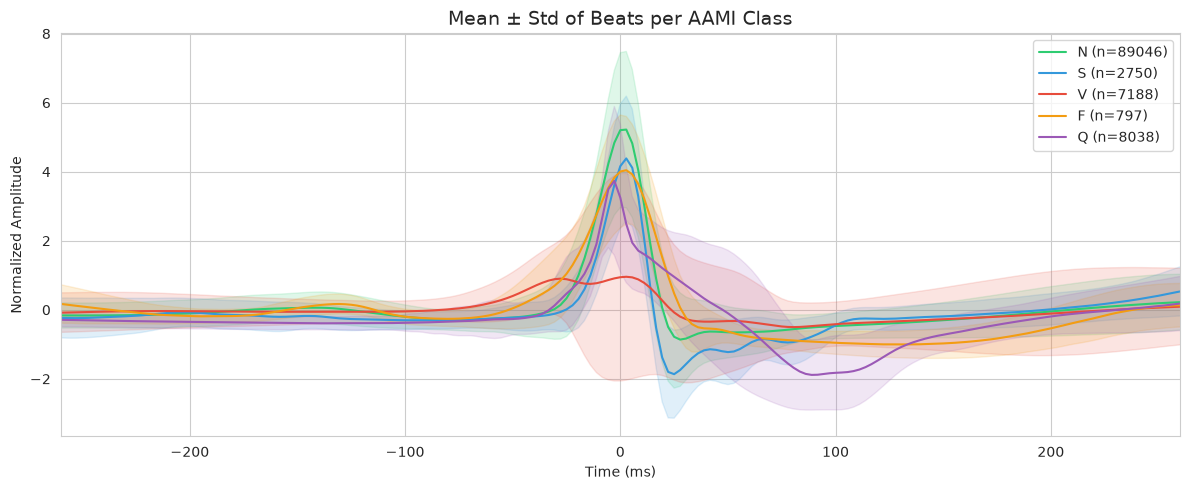

In [33]:
### 4.3 Mean Beat Shape per Class (with std shading)

fig, ax = plt.subplots(figsize=(12, 5))
x_axis = np.arange(-BEAT_WINDOW, BEAT_WINDOW) / 360.0 * 1000  # ms
class_colors = {'N': '#2ecc71', 'S': '#3498db', 'V': '#e74c3c', 'F': '#f39c12', 'Q': '#9b59b6'}

for cls in classes_order:
    idxs = np.where(labels == cls)[0]
    cls_beats = beats_norm[idxs]
    mean = cls_beats.mean(axis=0)
    std  = cls_beats.std(axis=0)
    ax.plot(x_axis, mean, label=f'{cls} (n={len(idxs)})', color=class_colors[cls], linewidth=1.5)
    ax.fill_between(x_axis, mean - std, mean + std, alpha=0.15, color=class_colors[cls])

ax.set_title('Mean ± Std of Beats per AAMI Class', fontsize=14)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Normalized Amplitude')
ax.legend()
ax.set_xlim([-260, 260])
plt.tight_layout()
plt.show()

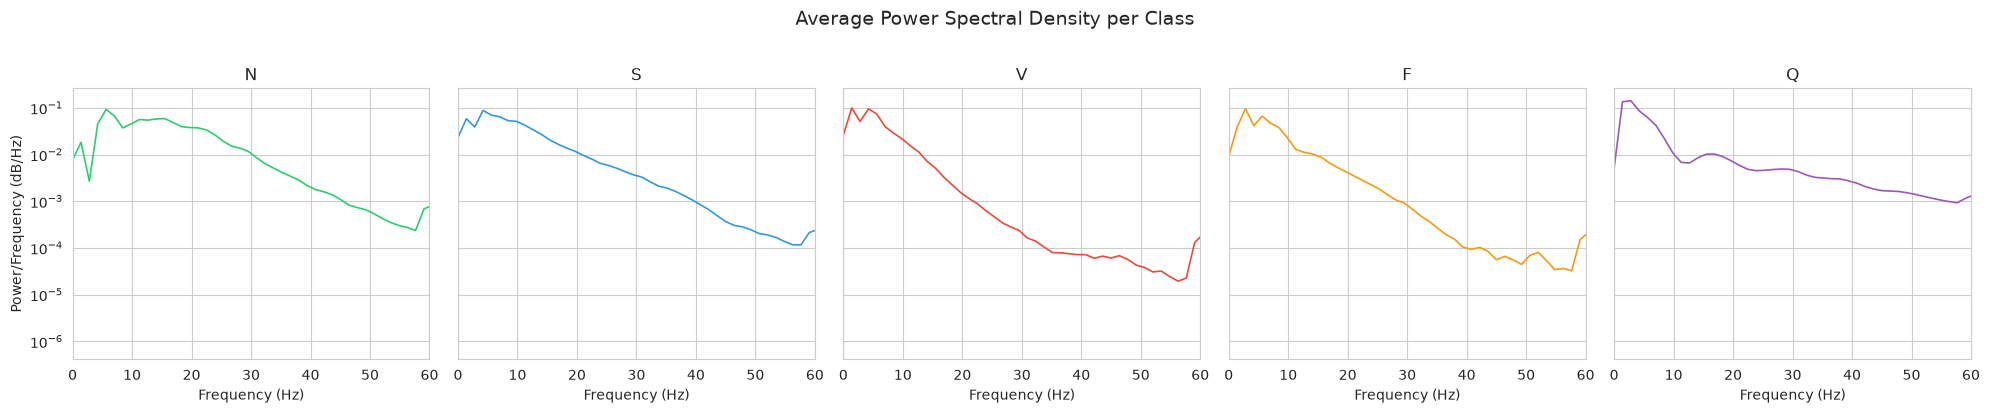

In [34]:
### 4.4 Power Spectral Density per Class

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fs = 360  # Hz

for ax, cls in zip(axes, classes_order):
    idxs = np.where(labels == cls)[0]
    # Average PSD over up to 200 beats to keep it fast
    sample_n = min(200, len(idxs))
    psds = []
    for j in idxs[:sample_n]:
        f, pxx = signal.welch(beats_norm[j], fs=fs, nperseg=min(256, BEAT_WINDOW * 2))
        psds.append(pxx)
    psds = np.array(psds)
    mean_psd = psds.mean(axis=0)
    ax.semilogy(f, mean_psd, color=class_colors[cls], linewidth=1.2)
    ax.set_title(f'{cls}', fontsize=12)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_xlim([0, 60])

axes[0].set_ylabel('Power/Frequency (dB/Hz)')
plt.suptitle('Average Power Spectral Density per Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Filter designs:
  Bandpass  : 0.5–40 Hz, 4th-order Butterworth
  Notch     : 60 Hz, Q=30


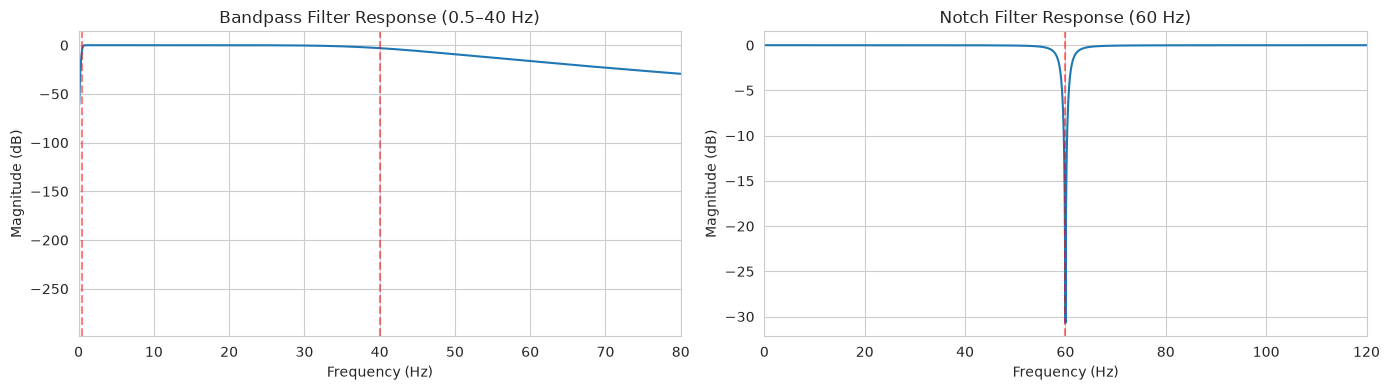

In [35]:
### 5.1 Design Filters

# Bandpass: 4th-order Butterworth, 0.5–40 Hz
sos_bp = signal.butter(4, [0.5, 40], btype='band', fs=360, output='sos')

# Notch: 60 Hz with Q=30
b_notch, a_notch = signal.iirnotch(60, Q=30, fs=360)

print("Filter designs:")
print(f"  Bandpass  : 0.5–40 Hz, 4th-order Butterworth")
print(f"  Notch     : 60 Hz, Q=30")

# Quick frequency-response check
w, h_bp = signal.sosfreqz(sos_bp, worN=2048, fs=360)
w2, h_notch = signal.freqz(b_notch, a_notch, worN=2048, fs=360)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(w, 20 * np.log10(np.abs(h_bp)))
axes[0].set_title('Bandpass Filter Response (0.5–40 Hz)')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Magnitude (dB)')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5)
axes[0].axvline(40, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlim([0, 80])

axes[1].plot(w2, 20 * np.log10(np.abs(h_notch)))
axes[1].set_title('Notch Filter Response (60 Hz)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude (dB)')
axes[1].axvline(60, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlim([0, 120])

plt.tight_layout()
plt.show()

In [36]:
### 5.2 Apply Filters to Raw Signal & Re-extract Beats

def clean_signal(sig, fs=360):
    """Apply bandpass + notch to a raw ECG signal."""
    # Zero-phase bandpass
    filtered = signal.sosfiltfilt(sos_bp, sig)
    # Zero-phase notch at 60 Hz
    filtered = signal.filtfilt(b_notch, a_notch, filtered)
    return filtered

# Clean every record and re-extract beat windows
clean_beat_signals = []

for rec in records:
    raw_sig = rec['record'].p_signal[:, rec['ch_idx']]   # MLII channel
    cleaned = clean_signal(raw_sig)
    ann = rec['annotation']

    for sample, sym in zip(ann.sample, ann.symbol):
        aami_cls = AAMI_MAP.get(sym)
        if aami_cls is None:
            continue
        if sample - BEAT_WINDOW < 0 or sample + BEAT_WINDOW >= len(cleaned):
            continue
        window = cleaned[sample - BEAT_WINDOW : sample + BEAT_WINDOW]
        clean_beat_signals.append((window, aami_cls))

clean_beats = np.array([b for b, _ in clean_beat_signals], dtype=np.float32)
clean_labels = np.array([c for _, c in clean_beat_signals])

# Normalize
clean_means = clean_beats.mean(axis=1, keepdims=True)
clean_stds  = clean_beats.std(axis=1, keepdims=True)
clean_stds[clean_stds == 0] = 1
clean_beats_norm = (clean_beats - clean_means) / clean_stds

print(f"Clean beats shape: {clean_beats_norm.shape}")
print(f"Clean class counts: {dict(Counter(clean_labels))}")

Clean beats shape: (107819, 372)
Clean class counts: {np.str_('N'): 89046, np.str_('S'): 2750, np.str_('V'): 7188, np.str_('Q'): 8038, np.str_('F'): 797}


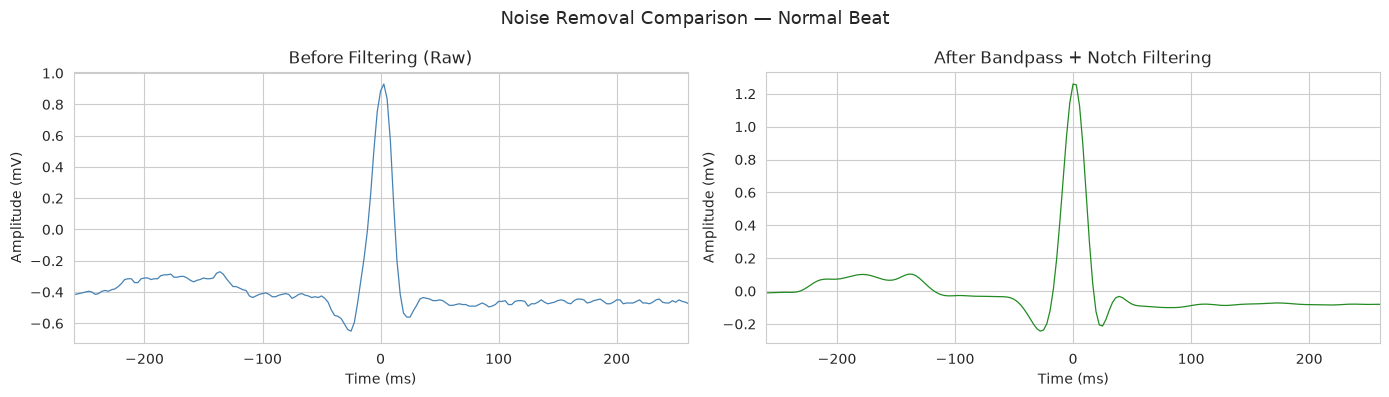

In [37]:
### 5.3 Before vs. After Filtering (single beat)

# Pick a random Normal beat
sample_idx = np.where(labels == 'N')[0][42]
raw_beat = beats[sample_idx]
clean_beat = clean_beats[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x_ms = np.arange(-BEAT_WINDOW, BEAT_WINDOW) / 360.0 * 1000

axes[0].plot(x_ms, raw_beat, linewidth=0.9, color='steelblue')
axes[0].set_title('Before Filtering (Raw)')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].set_xlim([-260, 260])

axes[1].plot(x_ms, clean_beat, linewidth=0.9, color='forestgreen')
axes[1].set_title('After Bandpass + Notch Filtering')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].set_xlim([-260, 260])

plt.suptitle('Noise Removal Comparison — Normal Beat', fontsize=13)
plt.tight_layout()
plt.show()

In [39]:
### 6.1 Time-Domain Features

def extract_time_features(beat, fs=360):
    """Extract time-domain features from a single beat window."""
    feat = {}
    feat['mean']     = np.mean(beat)
    feat['std']      = np.std(beat)
    feat['skew']     = skew(beat)
    feat['kurtosis'] = kurtosis(beat)
    feat['min']      = np.min(beat)
    feat['max']      = np.max(beat)
    feat['range']    = feat['max'] - feat['min']
    feat['median']   = np.median(beat)
    feat['iqr']      = np.percentile(beat, 75) - np.percentile(beat, 25)
    feat['rms']      = np.sqrt(np.mean(beat ** 2))
    feat['energy']   = np.sum(beat ** 2)
    feat['zero_crossings'] = np.sum(np.diff(np.sign(beat)) != 0)

    # Peak characteristics
    peak_idx = np.argmax(np.abs(beat))
    feat['peak_idx']   = peak_idx
    feat['peak_val']   = beat[peak_idx]
    feat['half_width'] = _half_width(beat, peak_idx)

    # Slope features
    diff1 = np.diff(beat)
    feat['mean_slope'] = np.mean(diff1)
    feat['max_slope']  = np.max(np.abs(diff1))

    # Area under curve
    feat['area'] = np.trapezoid(np.abs(beat))

    return feat


def _half_width(beat, peak_idx):
    """Compute half-width of the main peak."""
    half_val = beat[peak_idx] / 2.0
    left = peak_idx
    while left > 0 and beat[left] > half_val:
        left -= 1
    right = peak_idx
    while right < len(beat) - 1 and beat[right] > half_val:
        right += 1
    return (right - left) / 360.0 * 1000  # in ms


# Extract time-domain features for all clean beats
time_features_list = [extract_time_features(b) for b in clean_beats_norm]
time_df = pd.DataFrame(time_features_list)
print(f"Time-domain feature matrix: {time_df.shape}")
time_df.head()

Time-domain feature matrix: (107819, 18)


,mean,std,skew,kurtosis,min,max,range,median,iqr,rms,energy,zero_crossings,peak_idx,peak_val,half_width,mean_slope,max_slope,area
0,1.538184e-08,1.0,5.380630,33.100914,-1.236220,7.560256,8.796475,-0.058984,0.519474,1.0,371.999969,10,186,7.560256,22.222222,0.001359,1.611747,154.837387
1,-1.025456e-08,1.0,5.661803,37.858673,-1.569952,7.997454,9.567406,-0.067432,0.574779,1.0,372.000031,10,186,7.997454,19.444444,0.001883,2.067215,157.572174
2,2.563641e-09,1.0,5.379539,35.909019,-1.984739,7.872567,9.857306,-0.125375,0.532821,1.0,371.999939,10,186,7.872567,19.444444,0.001347,2.040349,162.606201
3,-1.025456e-08,1.0,5.298018,35.105495,-1.704745,7.995075,9.699820,-0.043061,0.661242,1.0,371.999939,15,186,7.995075,19.444444,0.001121,2.063137,170.369873
4,1.025456e-08,1.0,5.134755,33.134121,-1.516956,7.812695,9.329651,-0.013152,0.699452,1.0,372.000000,14,186,7.812695,19.444444,0.001743,1.966738,173.450958


In [ ]:
### 6.2 Frequency-Domain Features

def extract_freq_features(beat, fs=360):
    """Extract frequency-domain features from a single beat window."""
    feat = {}
    N = len(beat)
    fft_vals = np.abs(fft(beat))[:N // 2]
    freqs = fftfreq(N, 1.0 / fs)[:N // 2]
    total_power = np.sum(fft_vals ** 2) + 1e-12

    # Band powers
    bands = {'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 13),
             'beta': (13, 30), 'gamma': (30, 50)}
    for bname, (lo, hi) in bands.items():
        mask = (freqs >= lo) & (freqs < hi)
        feat[f'power_{bname}'] = np.sum(fft_vals[mask] ** 2)
        feat[f'ratio_{bname}'] = feat[f'power_{bname}'] / total_power

    # Dominant frequency
    feat['dominant_freq'] = freqs[np.argmax(fft_vals)]

    # Spectral entropy
    psd = (fft_vals ** 2) / total_power
    psd = psd[psd > 0]
    feat['spectral_entropy'] = -np.sum(psd * np.log2(psd))

    # Centroid & bandwidth
    feat['spectral_centroid'] = np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-12)
    feat['spectral_bandwidth'] = np.sqrt(
        np.sum(((freqs - feat['spectral_centroid']) ** 2) * fft_vals) / (np.sum(fft_vals) + 1e-12)
    )

    return feat


freq_features_list = [extract_freq_features(b) for b in clean_beats_norm]
freq_df = pd.DataFrame(freq_features_list)
print(f"Frequency-domain feature matrix: {freq_df.shape}")
freq_df.head()

Frequency-domain feature matrix: (107819, 14)


,power_delta,ratio_delta,power_theta,ratio_theta,power_alpha,ratio_alpha,power_beta,ratio_beta,power_gamma,ratio_gamma,dominant_freq,spectral_entropy,spectral_centroid,spectral_bandwidth
0,10595.406250,0.153131,15693.076172,0.226805,15442.387695,0.223182,26835.505859,0.387841,608.246399,0.008791,4.838710,4.735905,17.112560,19.224909
1,8292.772461,0.119852,12870.128906,0.186006,12866.139648,0.185949,32573.183594,0.470766,2554.606934,0.036921,6.774194,5.010813,20.169220,21.397268
2,4785.132324,0.069157,13582.681641,0.196304,14970.889648,0.216367,33574.878906,0.485242,2259.364746,0.032654,6.774194,4.922972,19.415921,18.968216
3,8995.820312,0.130013,12075.060547,0.174515,12642.830078,0.182721,32858.679688,0.474892,2605.870850,0.037661,5.806452,5.006901,18.900271,18.020572
4,9946.506836,0.143752,12997.513672,0.187847,12690.538086,0.183411,31348.228516,0.453062,2181.584473,0.031529,4.838710,4.957933,19.520894,20.707142


In [ ]:
### 6.3 Wavelet Features (Discrete Wavelet Transform)

def extract_wavelet_features(beat, wavelet='db4', level=5):
    """Extract energy + entropy from DWT coefficients."""
    feat = {}
    coeffs = pywt.wavedec(beat, wavelet, level=level)

    total_energy = sum(np.sum(c ** 2) for c in coeffs) + 1e-12

    for i, c in enumerate(coeffs):
        label = f'approx_{i}' if i == 0 else f'detail_{i}'
        energy = np.sum(c ** 2)
        feat[f'wav_energy_{label}'] = energy
        feat[f'wav_ratio_{label}'] = energy / total_energy

        # Wavelet entropy
        p = energy / total_energy
        feat[f'wav_entropy_{label}'] = -p * np.log2(p + 1e-12)

        feat[f'wav_std_{label}'] = np.std(c)
        feat[f'wav_mean_{label}'] = np.mean(c)
        feat[f'wav_max_{label}']  = np.max(np.abs(c))

    return feat


wavelet_features_list = [extract_wavelet_features(b) for b in clean_beats_norm]
wavelet_df = pd.DataFrame(wavelet_features_list)
print(f"Wavelet feature matrix: {wavelet_df.shape}")
wavelet_df.head()

Wavelet feature matrix: (107819, 36)


,wav_energy_approx_0,wav_ratio_approx_0,wav_entropy_approx_0,wav_std_approx_0,wav_mean_approx_0,wav_max_approx_0,wav_energy_detail_1,wav_ratio_detail_1,wav_entropy_detail_1,wav_std_detail_1,...,wav_entropy_detail_4,wav_std_detail_4,wav_mean_detail_4,wav_max_detail_4,wav_energy_detail_5,wav_ratio_detail_5,wav_entropy_detail_5,wav_std_detail_5,wav_mean_detail_5,wav_max_detail_5
0,101.160950,0.243956,0.496525,2.212100,-0.852448,5.102764,188.878738,0.455492,0.516757,3.162951,...,0.029542,0.124236,-0.000308,0.715878,0.012178,0.000029,0.000442,0.008027,0.000002,0.061482
1,119.389305,0.265615,0.508013,2.294733,-1.169162,4.455030,158.386795,0.352375,0.530260,2.913768,...,0.062455,0.205889,-0.000348,1.333436,0.038336,0.000085,0.001153,0.014242,0.000002,0.105496
2,73.277100,0.172745,0.437612,1.773177,-0.962701,3.733421,174.527588,0.411435,0.527157,3.042821,...,0.061334,0.197724,0.000061,1.322029,0.035475,0.000084,0.001133,0.013700,-0.000005,0.100889
3,58.125069,0.152090,0.413229,1.755044,-0.385995,4.441897,154.243546,0.403594,0.528314,2.864008,...,0.069155,0.202605,-0.000072,1.260579,0.039864,0.000104,0.001380,0.014523,-0.000002,0.113733
4,138.596939,0.303973,0.522221,2.502691,-1.198485,4.530753,159.634201,0.350113,0.530109,2.914400,...,0.052466,0.185744,0.000164,1.155845,0.034157,0.000075,0.001027,0.013443,-0.000005,0.105903


In [ ]:
### 6.4 Combine All Features

features_df = pd.concat([time_df, freq_df, wavelet_df], axis=1)
features_df['class'] = clean_labels

print(f"Combined feature matrix: {features_df.shape}")
print(f"\nFeature columns ({len(features_df.columns) - 1} features + class):")
print(list(features_df.columns[:10]), '...', list(features_df.columns[-10:]))

Combined feature matrix: (107819, 69)

Feature columns (68 features + class):
['mean', 'std', 'skew', 'kurtosis', 'min', 'max', 'range', 'median', 'iqr', 'rms'] ... ['wav_std_detail_4', 'wav_mean_detail_4', 'wav_max_detail_4', 'wav_energy_detail_5', 'wav_ratio_detail_5', 'wav_entropy_detail_5', 'wav_std_detail_5', 'wav_mean_detail_5', 'wav_max_detail_5', 'class']


In [ ]:
from sklearn.feature_selection import VarianceThreshold, f_classif, SelectKBest

# Separate features and labels
X = features_df.drop(columns=['class']).values
y = features_df['class'].values
feature_names = [c for c in features_df.columns if c != 'class']

# Handle NaN / inf
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f"X shape: {X.shape}, y shape: {y.shape}")

# 1) Variance threshold — drop features with near-zero variance
vt = VarianceThreshold(threshold=0.01)
X_vt = vt.fit_transform(X)
kept_mask = vt.get_support()
kept_names = [n for n, k in zip(feature_names, kept_mask) if k]
print(f"\nAfter variance threshold: {X_vt.shape[1]} features kept (dropped {X.shape[1] - X_vt.shape[1]})")

X shape: (107819, 68), y shape: (107819,)

After variance threshold: 46 features kept (dropped 22)


In [ ]:
### 7.2 Correlation Filter — remove redundant features

corr_matrix = np.corrcoef(X_vt, rowvar=False)
upper_tri = np.triu(np.abs(corr_matrix), k=1)

# Remove features with correlation > 0.95
drop_idx = set()
for i in range(upper_tri.shape[0]):
    for j in range(i + 1, upper_tri.shape[1]):
        if upper_tri[i, j] > 0.95:
            drop_idx.add(j)

keep_idx_corr = [i for i in range(X_vt.shape[1]) if i not in drop_idx]
X_corr = X_vt[:, keep_idx_corr]
corr_names = [kept_names[i] for i in keep_idx_corr]
print(f"After correlation filter: {X_corr.shape[1]} features (dropped {X_vt.shape[1] - X_corr.shape[1]} redundant)")

# 3) ANOVA F-test — rank by class discriminability
selector = SelectKBest(f_classif, k=min(25, X_corr.shape[1]))
X_selected = selector.fit_transform(X_corr, y)
selected_mask = selector.get_support()
selected_names = [n for n, s in zip(corr_names, selected_mask) if s]
f_scores = selector.scores_[selected_mask]

print(f"After ANOVA F-test (top {X_selected.shape[1]}): {X_selected.shape[1]} features selected")

# Show top features
f_ranking = sorted(zip(selected_names, f_scores), key=lambda x: -x[1])
print("\nTop 15 features by ANOVA F-score:")
for name, score in f_ranking[:15]:
    print(f"  {name:30s} F={score:.1f}")

After correlation filter: 40 features (dropped 6 redundant)
After ANOVA F-test (top 25): 25 features selected

Top 15 features by ANOVA F-score:
  power_alpha                    F=18332.0
  wav_max_detail_1               F=13890.6
  wav_mean_detail_1              F=11892.3
  power_delta                    F=11592.5
  spectral_entropy               F=10638.9
  wav_entropy_approx_0           F=9387.4
  max                            F=9199.9
  peak_val                       F=7468.0
  wav_ratio_approx_0             F=7202.8
  range                          F=6223.7
  skew                           F=6084.1
  wav_entropy_detail_3           F=5798.7
  wav_ratio_detail_1             F=5785.8
  kurtosis                       F=5750.4
  power_beta                     F=5395.0


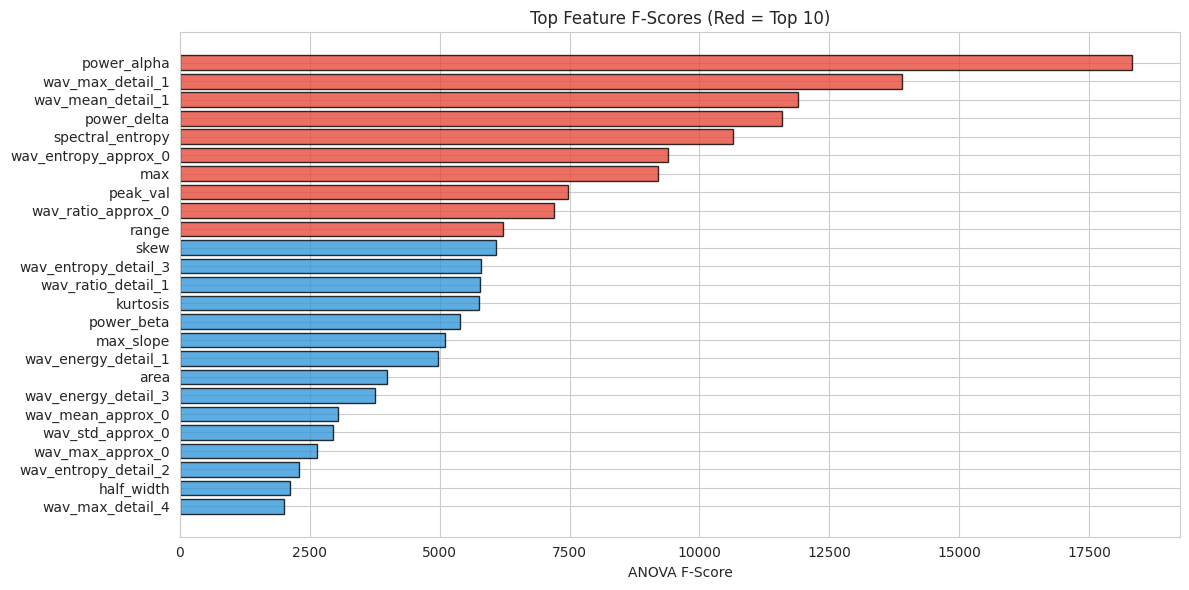

In [ ]:
### 7.3 Visualize Selected Feature F-Scores

fig, ax = plt.subplots(figsize=(12, 6))
names_sorted = [n for n, _ in f_ranking]
scores_sorted = [s for _, s in f_ranking]

colors_bar = ['#e74c3c' if i < 10 else '#3498db' for i in range(len(names_sorted))]
ax.barh(names_sorted[::-1], scores_sorted[::-1], color=colors_bar[::-1], edgecolor='black', alpha=0.8)
ax.set_xlabel('ANOVA F-Score')
ax.set_title('Top Feature F-Scores (Red = Top 10)')
plt.tight_layout()
plt.show()

In [ ]:
### 8.1 Signal-Level Augmentation Functions

def augment_noise(beat, noise_ratio=0.05):
    """Add Gaussian noise scaled by signal std."""
    noise = np.random.normal(0, beat.std() * noise_ratio, size=beat.shape)
    return beat + noise

def augment_shift(beat, max_shift=15):
    """Random circular shift."""
    shift = np.random.randint(-max_shift, max_shift + 1)
    return np.roll(beat, shift)

def augment_scale(beat, scale_range=(0.8, 1.2)):
    """Random amplitude scaling."""
    scale = np.random.uniform(*scale_range)
    return beat * scale

def augment_time_warp(beat, sigma=0.2):
    """Random time warping using cubic interpolation."""
    orig_len = len(beat)
    # Random displacement field
    displacement = np.cumsum(np.random.normal(0, sigma, size=orig_len // 10))
    displacement = np.interp(np.linspace(0, len(displacement) - 1, orig_len),
                             np.arange(len(displacement)), displacement)
    template = np.linspace(0, orig_len - 1, orig_len) + displacement
    template = np.clip(template, 0, orig_len - 1)
    warped = np.interp(template, np.arange(orig_len), beat)
    return warped

print("Augmentation functions defined.")

Augmentation functions defined.


In [ ]:
### 8.2 Apply Augmentation to Minority Classes

# Determine target count = count of second-largest class
class_counts = Counter(clean_labels)
target_count = max(class_counts.values())  # match the majority

np.random.seed(42)
aug_beats = list(clean_beats_norm)
aug_labels = list(clean_labels)

for cls, count in class_counts.items():
    if count >= target_count:
        continue  # already balanced

    need = target_count - count
    cls_indices = np.where(clean_labels == cls)[0]
    print(f"  {cls}: {count} → {target_count}  (+{need} synthetic)")

    for _ in range(need):
        idx = np.random.choice(cls_indices)
        orig = clean_beats_norm[idx].copy()

        # Randomly choose one augmentation
        aug_fn = np.random.choice([augment_noise, augment_shift, augment_scale, augment_time_warp])
        aug_beat = aug_fn(orig)

        # Re-normalize
        aug_beat = (aug_beat - aug_beat.mean()) / (aug_beat.std() + 1e-12)

        aug_beats.append(aug_beat)
        aug_labels.append(cls)

aug_beats = np.array(aug_beats, dtype=np.float32)
aug_labels = np.array(aug_labels)

print(f"\nAfter augmentation: {aug_beats.shape[0]} total beats")
print(f"Class distribution: {dict(Counter(aug_labels))}")

  S: 2750 → 89046  (+86296 synthetic)
  V: 7188 → 89046  (+81858 synthetic)
  Q: 8038 → 89046  (+81008 synthetic)
  F: 797 → 89046  (+88249 synthetic)

After augmentation: 445230 total beats
Class distribution: {np.str_('N'): 89046, np.str_('S'): 89046, np.str_('V'): 89046, np.str_('Q'): 89046, np.str_('F'): 89046}


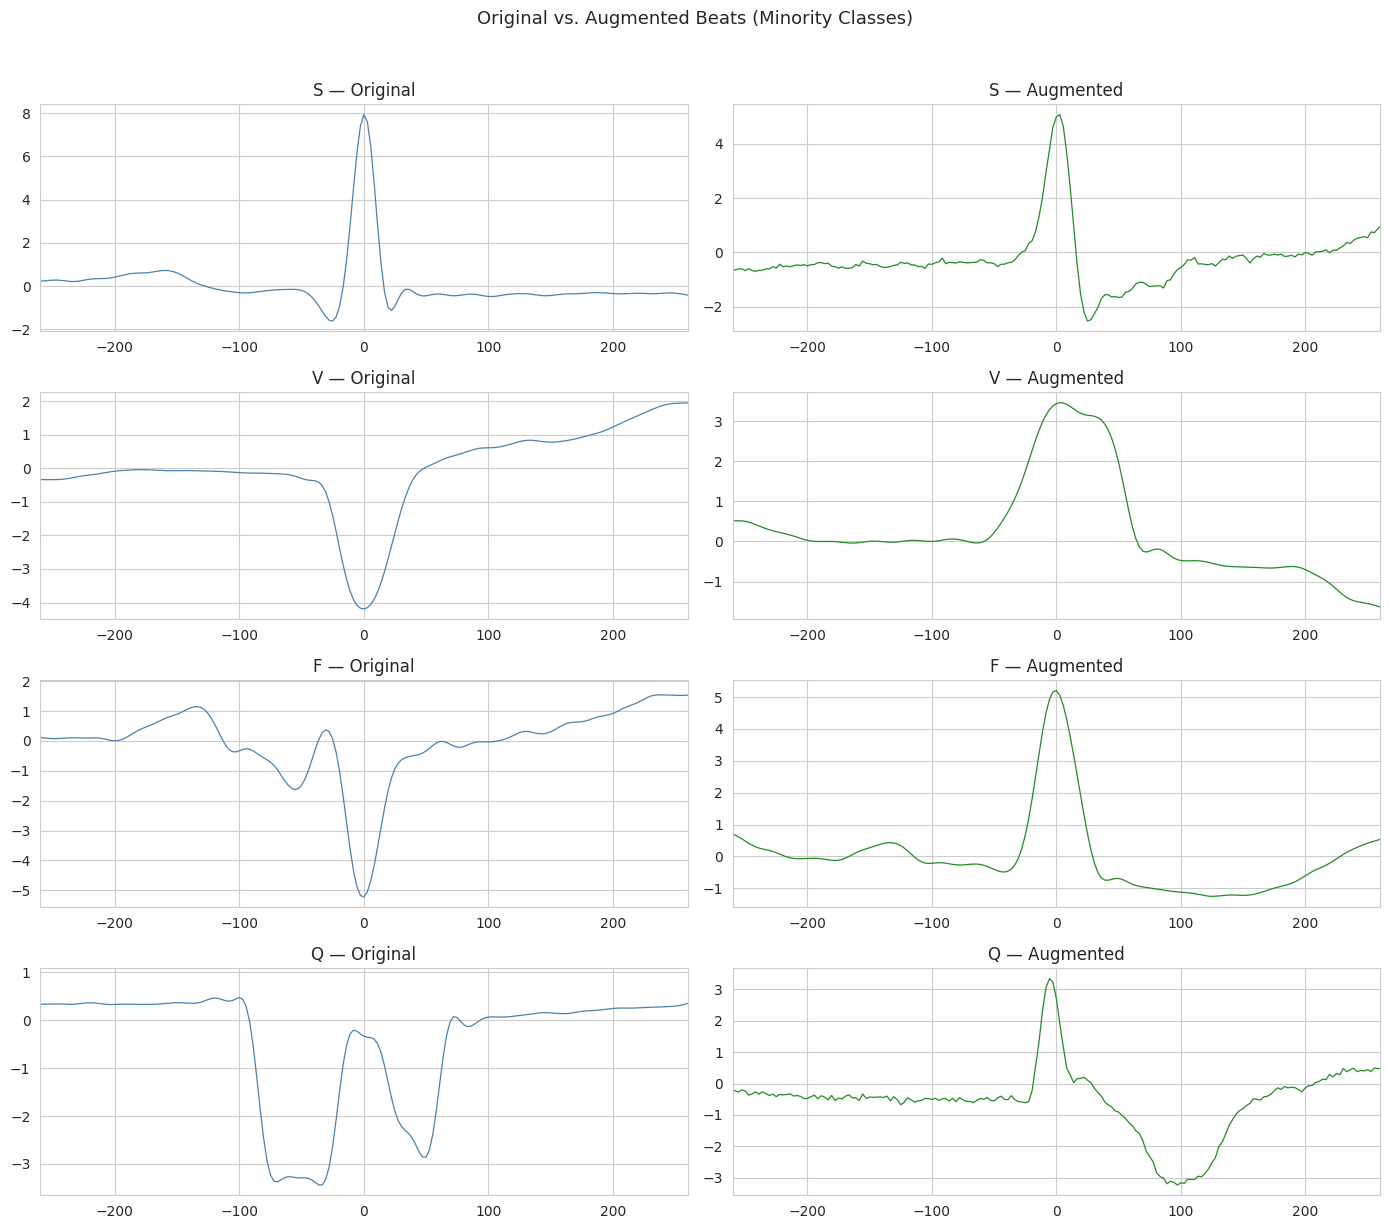

In [ ]:
### 8.3 Visualize Augmented Beats

# Show original vs augmented for each minority class
minority_classes = [c for c in ['S', 'V', 'F', 'Q'] if class_counts.get(c, 0) < target_count]

fig, axes = plt.subplots(len(minority_classes), 2, figsize=(14, 3 * len(minority_classes)))
if len(minority_classes) == 1:
    axes = axes.reshape(1, -1)

x_ms = np.arange(-BEAT_WINDOW, BEAT_WINDOW) / 360.0 * 1000

for row, cls in enumerate(minority_classes):
    # Original
    orig_idx = np.where(clean_labels == cls)[0][0]
    axes[row, 0].plot(x_ms, clean_beats_norm[orig_idx], color='steelblue', linewidth=0.9)
    axes[row, 0].set_title(f'{cls} — Original')
    axes[row, 0].set_xlim([-260, 260])

    # Augmented
    aug_cls_indices = np.where(aug_labels == cls)[0]
    # Find one that's different from original (near the end of the array)
    aug_idx = aug_cls_indices[-1]
    axes[row, 1].plot(x_ms, aug_beats[aug_idx], color='forestgreen', linewidth=0.9)
    axes[row, 1].set_title(f'{cls} — Augmented')
    axes[row, 1].set_xlim([-260, 260])

plt.suptitle('Original vs. Augmented Beats (Minority Classes)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

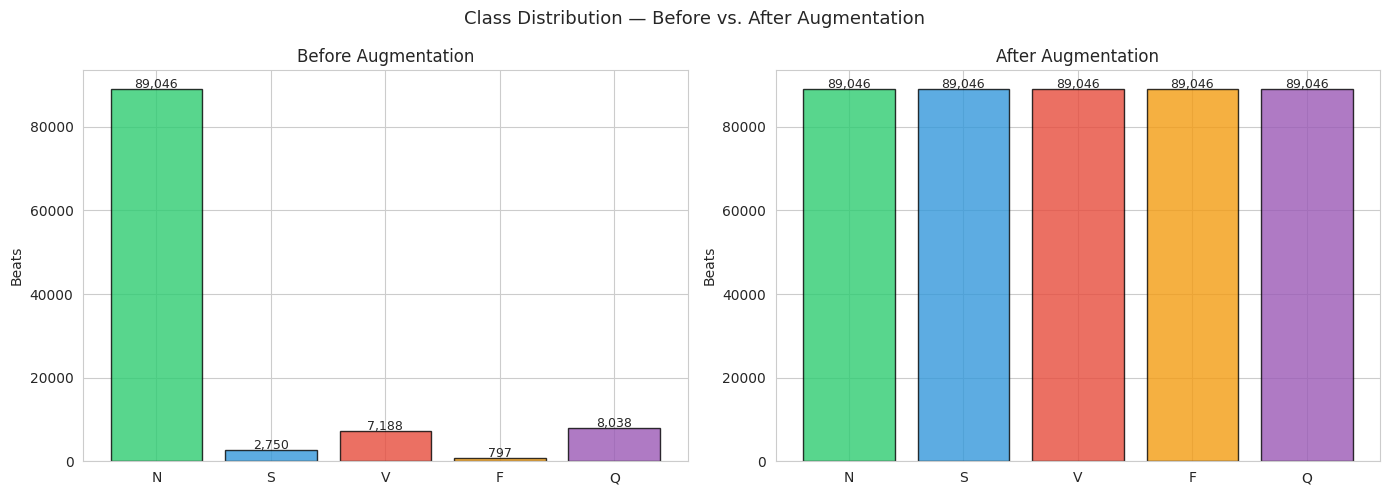

In [ ]:
### 8.4 Before vs. After Augmentation — Class Distribution Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
before_counts = [class_counts.get(c, 0) for c in classes_order]
axes[0].bar(classes_order, before_counts, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Before Augmentation')
axes[0].set_ylabel('Beats')
for i, v in enumerate(before_counts):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# After
after_counts = [Counter(aug_labels).get(c, 0) for c in classes_order]
axes[1].bar(classes_order, after_counts, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_title('After Augmentation')
axes[1].set_ylabel('Beats')
for i, v in enumerate(after_counts):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Class Distribution — Before vs. After Augmentation', fontsize=13)
plt.tight_layout()
plt.show()